In [1]:
print("Hi")

Hi


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score


In [2]:
df = pd.read_csv("creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(283726, 31)

In [3]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Logamount"] = np.log1p(df["Amount"])

print(df[["Amount","Logamount","Hour"]].head(10))

   Amount  Logamount  Hour
0  149.62   5.014760   0.0
1    2.69   1.305626   0.0
2  378.66   5.939276   0.0
3  123.50   4.824306   0.0
4   69.99   4.262539   0.0
5    3.67   1.541159   0.0
6    4.99   1.790091   0.0
7   40.80   3.732896   0.0
8   93.20   4.545420   0.0
9    3.68   1.543298   0.0


In [16]:
print(df["Hour"].value_counts().sort_index())

Hour
0.0      7647
1.0      4208
2.0      3308
3.0      3487
4.0      2204
5.0      2988
6.0      4082
7.0      7233
8.0     10232
9.0     15767
10.0    16548
11.0    16781
12.0    15378
13.0    15323
14.0    16520
15.0    16374
16.0    16396
17.0    16130
18.0    16959
19.0    15566
20.0    16705
21.0    17629
22.0    15378
23.0    10883
Name: count, dtype: int64


In [4]:
train = df.iloc[:200000]
prod  = df.iloc[200000:]

print(train.shape)
print(prod.shape)

(200000, 33)
(84807, 33)


In [ ]:
# Data drift
# Label drift 

train_fraud_rate = train["Class"].mean()
prod_fraud_rate = prod["Class"].mean()

print("Train fraud rate :", train_fraud_rate)
print("Production fraud rate :", prod_fraud_rate)

Train fraud rate : 0.001835
Production fraud rate : 0.0012660344456918997


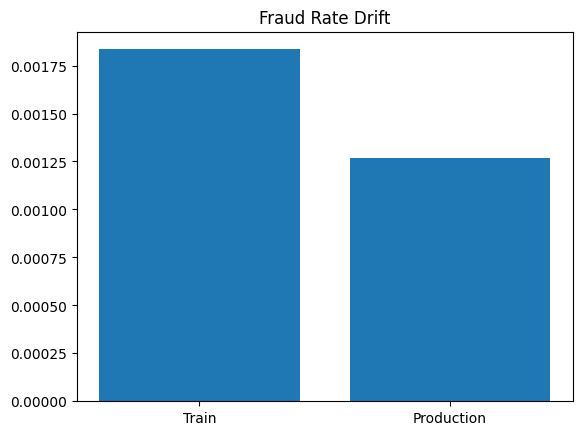

In [ ]:
plt.bar( ["Train","Production"],[train_fraud_rate, prod_fraud_rate])
plt.title("Fraud Rate Drift")
plt.show()

In [ ]:
# KS_stat Test

features = ["Amount","Logamount","V1","V2","V3"]

for feature in features:

    ks_stat,p_value = ks_2samp(train[feature],prod[feature])

    print(f"{feature}")
    print("KS Statistic:",round(ks_stat,4))
    print("P-value:",p_value)

    if p_value < 0.05:
        print("Drift Detected\n")
    else:
        print("No Drift\n")

Amount
KS Statistic: 0.0298
P-value: 4.8383506469998225e-46
Drift Detected

Logamount
KS Statistic: 0.0298
P-value: 4.8383506469998225e-46
Drift Detected

V1
KS Statistic: 0.3009
P-value: 0.0
Drift Detected

V2
KS Statistic: 0.0259
P-value: 9.579983422086493e-35
Drift Detected

V3
KS Statistic: 0.3968
P-value: 0.0
Drift Detected



In [27]:
def calculate_psi(expected, actual, buckets=10):

    breakpoints = np.linspace(0,100,buckets+1)

    bins = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(
        expected,
        bins=bins
    )[0]

    actual_counts = np.histogram(
        actual,
        bins=bins
    )[0]

    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    expected_perc = np.where(
        expected_perc == 0,
        0.0001,
        expected_perc
    )

    actual_perc = np.where(
        actual_perc == 0,
        0.0001,
        actual_perc
    )

    psi = np.sum(
        (actual_perc - expected_perc)
        * np.log(actual_perc / expected_perc)
    )

    return psi

In [28]:
features = ["Amount","Logamount","V1","V2","V3"]

for feature in features:

    psi_score = calculate_psi(train[feature],prod[feature])
    print(feature, "PSI =", round(psi_score,4))

Amount PSI = 0.004
Logamount PSI = 0.004
V1 PSI = 0.9575
V2 PSI = 0.0163
V3 PSI = 0.753


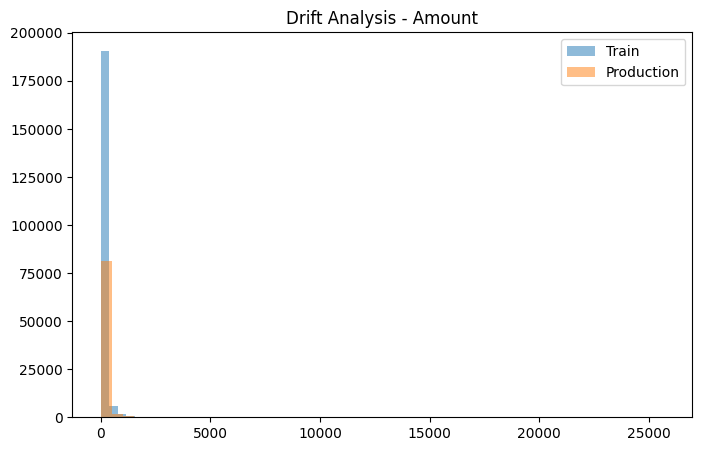

In [29]:
feature = "Amount"

plt.figure(figsize=(8,5))

plt.hist(
    train[feature],
    bins=50,
    alpha=0.5,
    label="Train"
)

plt.hist(
    prod[feature],
    bins=50,
    alpha=0.5,
    label="Production"
)

plt.legend()
plt.title(f"Drift Analysis - {feature}")
plt.show()

In [ ]:
report = []

for feature in ["Amount","Logamount","V1","V2","V3"]:

    ks_stat,p_value = ks_2samp(
        train[feature],
        prod[feature]
    )

    psi = calculate_psi(
        train[feature],
        prod[feature]
    )

    report.append([
        feature,
        round(ks_stat,4),
        round(p_value,4),
        round(psi,4)
    ])

drift_report = pd.DataFrame(
    report,
    columns=[
        "Feature",
        "KS Statistic",
        "P Value",
        "PSI"
    ]
)

print(drift_report)

drift_report.to_csv("drift_report.csv",index=False)

     Feature  KS Statistic  P Value     PSI
0     Amount        0.0298      0.0  0.0040
1  Logamount        0.0298      0.0  0.0040
2         V1        0.3009      0.0  0.9575
3         V2        0.0259      0.0  0.0163
4         V3        0.3968      0.0  0.7530


In [5]:
# concept drift

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [6]:
model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight="balanced")

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       1.00      0.73      0.85        98

    accuracy                           1.00     56962
   macro avg       1.00      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
prod_c = df.iloc[200000:].copy()


In [9]:
X_prod = prod_c.drop("Class", axis=1)
y_prod = prod_c["Class"]

prod_pred = model.predict(X_prod)

In [18]:
print("Accuracy:",accuracy_score(y_prod, prod_pred))

print("Recall:",recall_score(y_prod, prod_pred))

print("F1:",f1_score(y_prod, prod_pred))

Accuracy: 0.9995872982183075
Recall: 0.6822429906542056
F1: 0.8066298342541437


In [19]:
print("Accuracy:",accuracy_score(y_test, pred))

print("Recall:",recall_score(y_test, pred))

print("F1:",f1_score(y_test, pred))

Accuracy: 0.9995435553526912
Recall: 0.7346938775510204
F1: 0.8470588235294118


In [12]:
train = df.iloc[:200000].copy()
prod  = df.iloc[200000:].copy()

In [13]:
X_train = train.drop("Class", axis=1)
y_train = train["Class"]

X_prod = prod_c.drop("Class", axis=1)
y_prod = prod_c["Class"]

In [53]:
print(set(X_train.index).intersection(set(X_prod.index)))

set()


In [14]:
model.fit(X_train, y_train)
prod_pred = model.predict(X_prod)


In [15]:
print("Test Set")
print(classification_report(y_test, pred))

print("Production Set")
print(classification_report(y_prod, prod_pred))

Test Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       1.00      0.73      0.85        98

    accuracy                           1.00     56962
   macro avg       1.00      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Production Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84700
           1       0.99      0.68      0.81       107

    accuracy                           1.00     84807
   macro avg       0.99      0.84      0.90     84807
weighted avg       1.00      1.00      1.00     84807



In [16]:
features = ["Amount","Logamount","V1","V2","V3"]

for feature in features:
    ks,p = ks_2samp(train[feature], prod[feature])

    print(f"{feature}")
    print("P-value:", p)

    if p < 0.05:
        print("Drift Detected")
    else:
        print("No Drift")

Amount
P-value: 4.488852461178427e-47
Drift Detected
Logamount
P-value: 4.488852461178427e-47
Drift Detected
V1
P-value: 0.0
Drift Detected
V2
P-value: 7.886131529393312e-35
Drift Detected
V3
P-value: 0.0
Drift Detected


In [59]:
print("Train Fraud Rate:",
      train["Class"].mean())

print("Production Fraud Rate:",
      prod["Class"].mean())

Train Fraud Rate: 0.001835
Production Fraud Rate: 0.0012660344456918997
